In [1]:
from examples.seismic.datasets import VelocityModel, SeismogramDataset
import numpy as np
from examples.seismic.acoustic import AcousticWaveSolver, EikonalSolver
from matplotlib import pyplot as plt
from examples.seismic import SeismicModel, AcquisitionGeometry
from devito import configuration, info
from examples.seismic.utils import estimate_centroid_frequency_gather
from examples.seismic.plotting import overlay_wiggle_plot
configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"
configuration["compiler"] = "pgcc"

PATH_MODEL = "../data/South_ForMigr_2.dat"
PATH_DATA = path = "../data/21-20.sgy"
SO = 4
WAVELET = "Ricker"
NBL = 100

In [2]:
dataset = SeismogramDataset(PATH_DATA, "rec", invert_elevs=True)
xmin, xmax = min(dataset.x_coords.min(), dataset.opposite_x.min()), max(dataset.x_coords.max(), dataset.opposite_x.max())
spacing = (0.025, 0.025)
velmodel = VelocityModel(PATH_MODEL, dx=spacing[0], dz=spacing[1], clip=True, xmin=xmin-3, xmax=xmax+3, zmin=-318)
velmodel.pad_left(4)
velmodel.pad_right(8*int(0.5/spacing[0]))
velmodel.pad_bottom(10*int(0.5/spacing[0]))
velmodel.pad_top(7*int(0.5/spacing[0]))

(2298, 1462)


In [3]:
vp = velmodel.vp.T
print(np.max(vp))
print(np.min(vp))

dx_critical = 500/(10*2000)
print(dx_critical)

4.495380000000004
0.52462
0.025


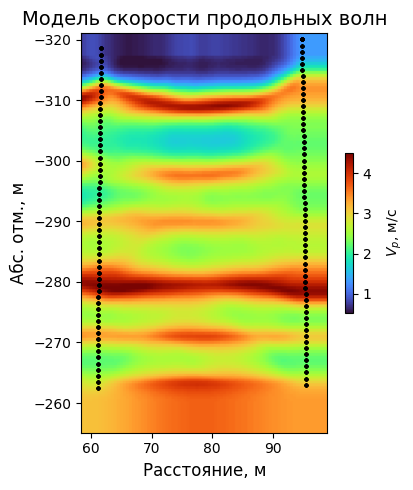

In [4]:
fig, axs = velmodel.plot_vp(show=False, figsize=(9, 5), dpi=100)
axs[0].scatter(dataset.x_coords, dataset.elevations, c='k', s=2)
axs[0].scatter(dataset.opposite_x, dataset.opposite_elev, c='k', s=2)
plt.show()

In [5]:
origin = velmodel.x[0], velmodel.z[0]
vp = velmodel.vp.T


model = SeismicModel(
    vp=vp,
    origin=origin,
    shape=vp.shape,
    spacing=spacing,
    space_order=SO,
    nbl=NBL,
    bcs="damp",
    fs=False,
)
t0 = 0.0
tn = dataset._t_max
dataset.dt_r = model.critical_dt
dataset.t_max_r = tn
dataset.resample_on()

f0 = 0.25

Operator `initdamp` ran in 0.15 s


In [ ]:
i = 10
d_2, sx, sz, rec_x, rec_z = dataset[i]
print(model.origin)
print(sx, sz)

d_2 *= -1
f0 = estimate_centroid_frequency_gather(d_2.T, model.critical_dt) / 1e3
info(f"Estimated gather centroid frequency: {f0*1e3:.2f} Hz, Wavelet length: {1/f0:.2f} ms")

src_pos = np.array([sx, sz])[None, :]
rec_pos = np.vstack([rec_x, rec_z]).T
f0 = f0 if WAVELET == "Ricker" else f0*2
geometry = AcquisitionGeometry(model, rec_pos, src_pos, t0, tn, f0=f0*2, src_type=WAVELET)
solver = AcousticWaveSolver(model, geometry, space_order=SO)

d_1, _, _ = solver.forward(vp=model.vp, save=False)

Estimated gather centroid frequency: 328.41 Hz, Wavelet length: 3.04 ms


(np.float32(58.4), np.float32(-321.02))
61.55 -308.52


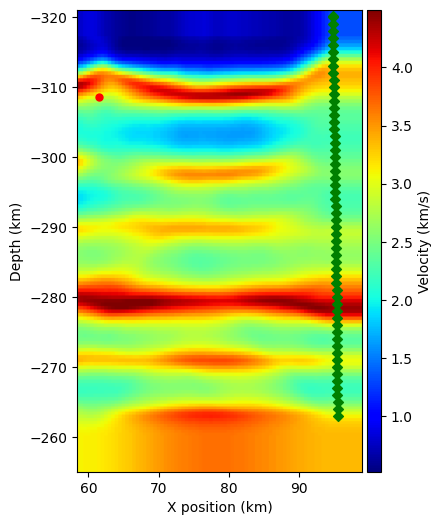

In [7]:
from examples.seismic import plot_velocity
plot_velocity(model, source=src_pos, receiver=rec_pos)


In [7]:
eikonal = EikonalSolver(velmodel, dataset)
field, hodograph = eikonal.solve_single(i)

In [8]:
print(hodograph)
print(hodograph.shape)

[12.95950032 12.88432814 12.13320401 11.38186713 10.64386558  9.99157316
  9.46804533  9.10767194  8.8900519   8.77180088  8.7390745   8.76326059
  8.84548375  8.99581998  9.22415612  9.47416736  9.73370489 10.01879803
 10.32730896 10.66277524 11.0069647  11.34486477 11.68249632 12.01178375
 12.33423365 12.6769333  13.03627489 13.38832696 13.7487322  14.08824339
 14.41034442 14.68866337 14.94566407 15.20765154 15.38566484 15.59322225
 15.82212439 15.97209423 16.07683828 16.16623875 16.25277337 16.33142548
 16.29963268 16.32629604 16.44325226 16.66148056 16.97591015 17.35273331
 17.73290374 18.08051494 18.38205661 18.67381856 19.00189241 19.37814352
 19.7572022  20.14720968 20.51916718 20.8432426  21.11926483]
(59,)


In [ ]:
# fig, ax = overlay_wiggle_plot(
#     np.array(d_1.data[:]), d_2.T, time_axis=geometry.time_axis.time_values, xrec=rec_z, title="Original vs Processed"
# )
# ax.plot(rec_z, hodograph, c='cyan')
# plt.show()

In [9]:
from examples.seismic import plot_shotrecord
plot_shotrecord(d_1)

NameError: name 'd_1' is not defined